# Computational Speed-ups

In [1]:
import ggml_ot
import scanpy as sc
import pandas as pd

This tutorial shows how to significantly improve computation speed of GGML for both EMD and Sinkhorn solvers. We use the Breast cancer dataset from *Kumar et al., 2023* containing 714,331 cells from 126 donors. 

In [2]:
id = "b8b5be07-061b-4390-af0a-f9ced877a068.h5ad"
adata = ggml_ot.data.load_cellxgene(id)
sc.pp.highly_variable_genes(adata, n_top_genes=1000, subset=True)

/home/kuehn/ot_metric_learning/gaussian-ground-metric-learning/code/ggml-ot_privat/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
# For ease of use, we define the reoccuring dataset and train parameters as a dict
dataset_params = {"patient_col": "donor_id", "label_col": "reported_diseases"}
train_params = {"n_splits": 1, "max_iter": 20}

# Dict to track the performance of different parameters
scores = {}

## Baseline (default)

First, we compute the normal GGML with the exact EMD solver as a baseline.

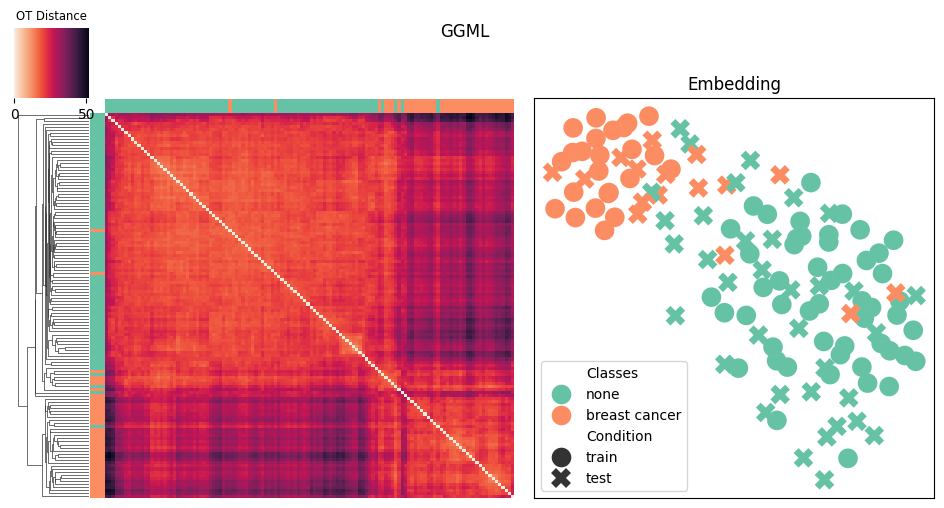

In [4]:
_, scores["default"] = ggml_ot.from_anndata(adata, **dataset_params).normalize().train_test(**train_params)

## Reduce `batch_size`

Smaller mini-batches run each OT subproblem on fewer distribution pairs per step, which lowers per-iteration cost.

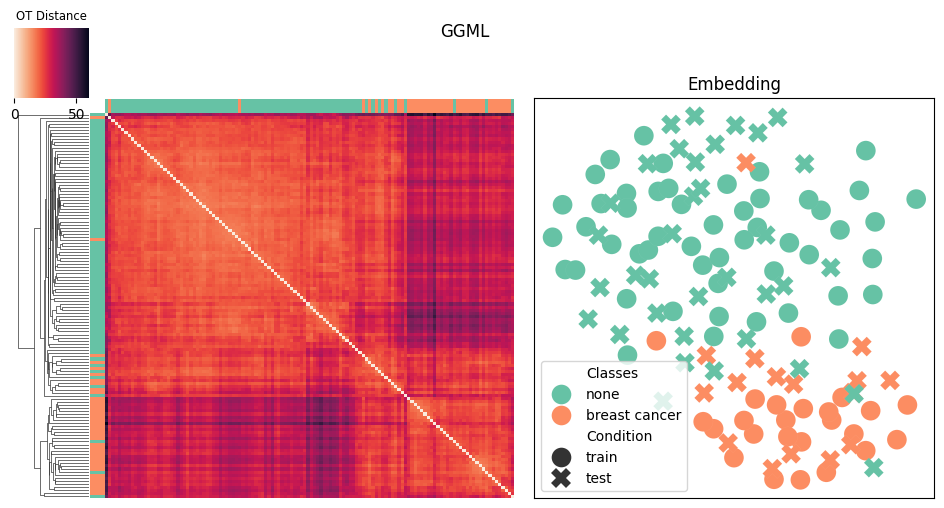

In [5]:
_, scores["reduced_batchsize"] = (
    ggml_ot.from_anndata(adata, **dataset_params).normalize().train_test(**train_params, batch_size=16)
)

## Low-dim. embeddings with `use_rep`

So far, we learned the ground metric for the Optimal Transport between the cells in the gene space `.X`. To use a low-dimensional representations (e.g. PCA, Harmony, ...) instead, pass the parameter `use_rep` when loading the dataset. While this improves the computation speed, it might significantly reduce the performance of GGML depending on the task-related information captured by the embedding.

*Note: If you AnnData has no `.obsm["X_pca"]` yet, compute it first with `sc.pp.pca(adata)`*


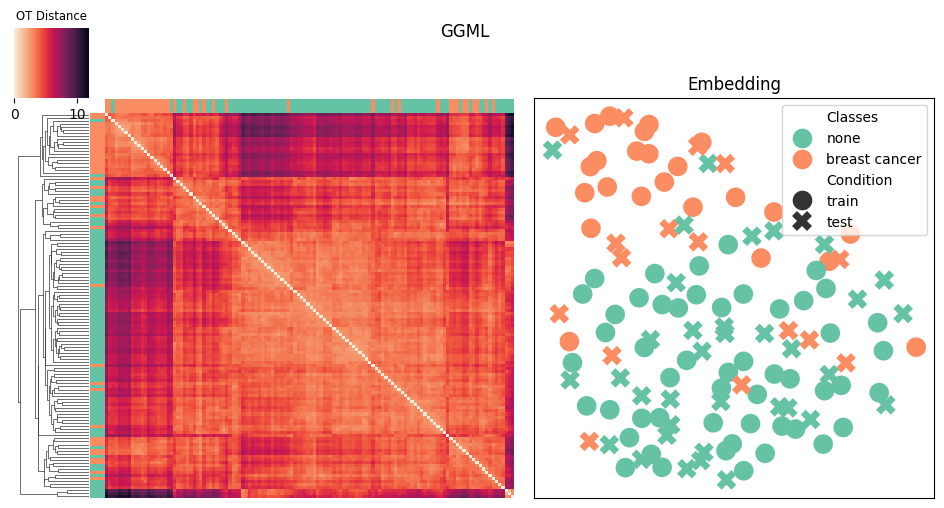

In [6]:
_, scores["use_rep"] = (
    ggml_ot.from_anndata(adata, **dataset_params, use_rep="X_pca").normalize().train_test(**train_params)
)

## Cluster cells with `group_by`

Another way to speed-up the computations, is to use Optimal Transport between cell subtypes instead of single cells. As patients have similar cell subtypes, the patient-specific distributions share the corresponding cluster centroids as supports. They only differ in the proportions of these cell subtypes which corresponds to different weights of the supports. 

While this approach improves the speed of the computation, it might significantly reduce the performance of GGML depending on the clustering. In particular, it can not learn any differences within a cluster, so the variance within a cell type is lost. As the existing `.obs["cell_type"]` in the AnnData of this tutorial is potentially too broad (i.e., high variance within clusters) to learn meaningful differences between patients, we compute more granular clusters with Leiden.

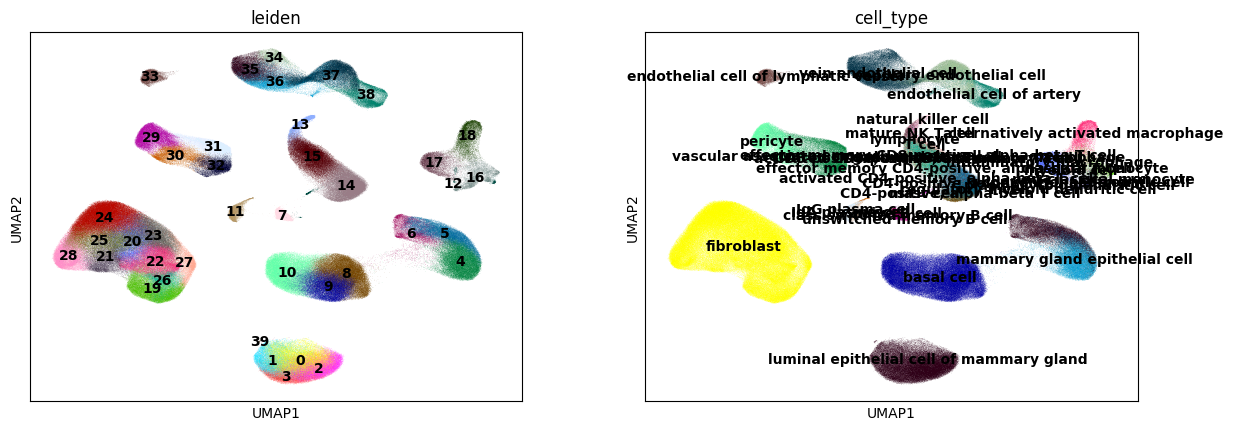

In [7]:
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.leiden(adata, flavor="igraph", resolution=2.0, n_iterations=2)
sc.pl.umap(adata, color=["leiden", "cell_type"], legend_loc="on data")

To group the cells according to our computed clusters, we use `group_by="leiden"` when creating our dataset. Now, we can learn the ground metric between the cluster centers instead of single cells which significantly speeds up the training.   

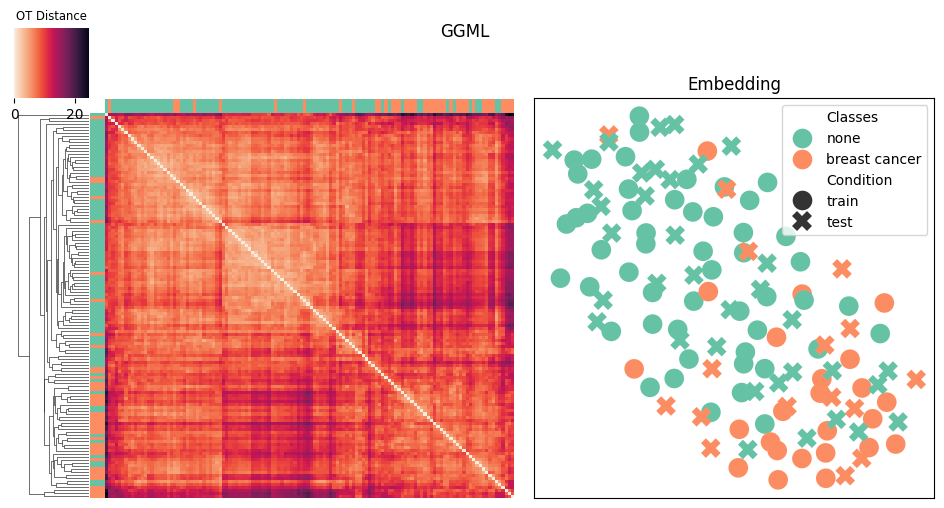

In [8]:
_, scores["group_by"] = (
    ggml_ot.from_anndata(adata, **dataset_params, group_by="leiden").normalize().train_test(**train_params)
)

## Combining `use_rep` and `group_by`

Here, we combine both computational improvements from above, which speeds-up the computation but further reduces the performance.

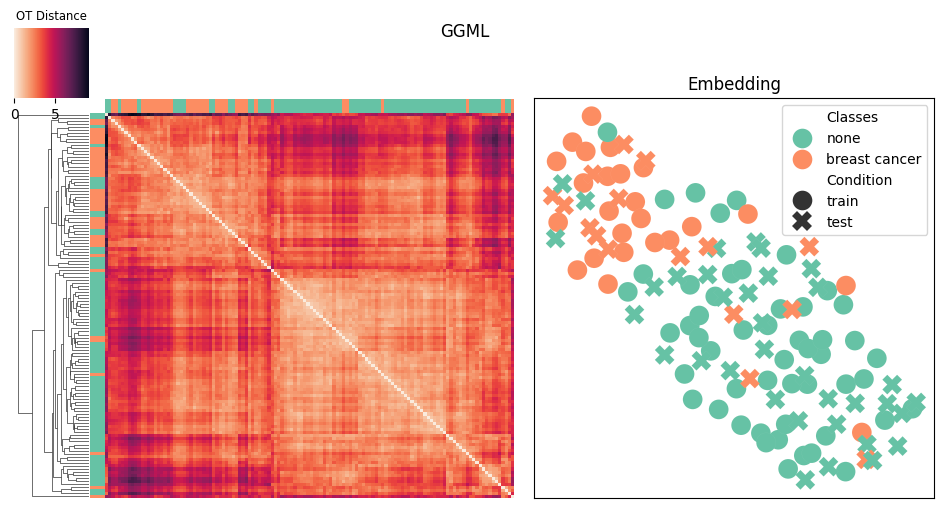

In [9]:
_, scores["use_rep + group_by"] = (
    ggml_ot.from_anndata(adata, **dataset_params, use_rep="X_pca", group_by="leiden")
    .normalize()
    .train_test(**train_params)
)

## Reduce number of sampled cells `n_cells`
Depending on the heterogeneity of cells per patient/sample, you might be able to significantly reduce the number of considered cells per patient/sample without reducing performance. Note that if you use the group_by parameter, `n_cells` will have no effect.

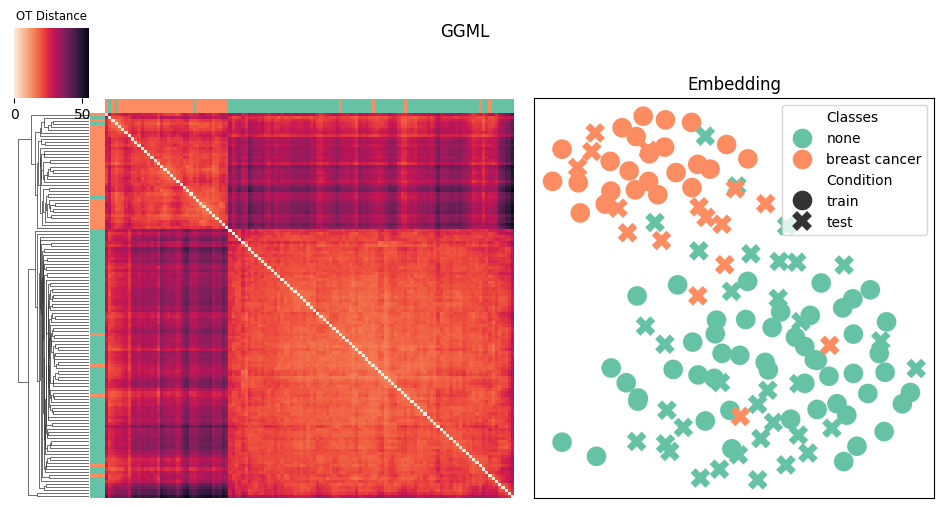

In [10]:
_, scores["n_cells"] = ggml_ot.from_anndata(adata, **dataset_params, n_cells=100).normalize().train_test(**train_params)

## Performance comparison of parameters


In [ ]:
scores_df = (
    pd.concat([scores[setup] for setup in scores], ignore_index=True)
    .set_index(pd.Index(scores.keys(), name="parameter"))
    .sort_values(("knn", "mean"), ascending=False)
)

ggml_ot.pl.table(scores_df, style_performance=True, title="Influence of parameters on performance and computation time")